# Brain Cancer (Tumor) Multi-Class Classification using CNN

##**Name:** Deep Talreja
##**Reg No:** 23BCE11003
##**Application Number:** IN26010914
###**Assignment 2** — MPOnline AI/ML Internship   

## Objective
The objective of this assignment is to develop a deep learning pipeline using a Convolutional Neural Network (CNN) to perform multiclass classification on Brain MRI images. The model will accurately classify the images into distinct types of brain tumors or identify a non-tumor state.

## Dataset Structure
The dataset used typically contains T1-weighted contrast-enhanced brain MRI images categorized into four primary classes:
1. **Glioma**
2. **Meningioma**
3. **Pituitary Tumor**
4. **No Tumor**


### STEP 1: IMPORT LIBRARIES & CONFIGURATION


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

# Set up parameters
BATCH_SIZE = 32
IMAGE_SIZE = (128, 128)
EPOCHS = 25
CHANNELS = 3 # RGB format

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### STEP 2: SIMULATED DATASET GENERATOR

In [ ]:
print("Initializing and generating multi-class data tensor arrays...")

# Simulating 1200 training images and 300 test images across 4 diagnostic classes
X_train_raw = np.random.rand(1200, IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS).astype('float32')
y_train_raw = np.random.randint(0, 4, size=(1200,))

X_test_raw = np.random.rand(300, IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS).astype('float32')
y_test_raw = np.random.randint(0, 4, size=(300,))

# Map class names
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

print(f"-> Training Dimensions: {X_train_raw.shape}")
print(f"-> Test Dimensions: {X_test_raw.shape}")
print(f"-> Target Diagnostic Classes: {class_names}")

Initializing and generating multi-class data tensor arrays...
-> Training Dimensions: (1200, 128, 128, 3)
-> Test Dimensions: (300, 128, 128, 3)
-> Target Diagnostic Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


### STEP 3: DATA AUGMENTATION PIPELINE

In [ ]:
# Creating layers for data augmentation to mitigate overfitting in medical imaging
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
])

### STEP 4: CNN ARCHITECTURE DESIGN

In [ ]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)),
    data_augmentation, # Apply augmentation at the input level

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Dense Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Output Layer for 4 Classes
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,060 (32.37 MB)

 Trainable params: 8,484,100 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

### STEP 5: MODEL TRAINING

In [ ]:
cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("\nExecuting Training Pipeline...")
history = model.fit(
    X_train_raw, y_train_raw,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=cb_list,
    verbose=1
)


Executing Training Pipeline...
Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.2552 - loss: 2.2220 - val_accuracy: 0.2917 - val_loss: 5.6305 - learning_rate: 0.0010
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.2385 - loss: 1.8634 - val_accuracy: 0.2917 - val_loss: 15.3996 - learning_rate: 0.0010
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.2427 - loss: 1.6483 - val_accuracy: 0.2917 - val_loss: 32.9591 - learning_rate: 0.0010
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2824 - loss: 1.5518
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
30/30 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.2802 - loss: 1.5697 - val_accuracy: 0.2917 - val_loss: 48.7473 - learning_rate: 0.0010
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.2510 - loss: 1.5682 - val_accuracy: 0.2917 - val_loss: 64.6548 - learning_rate: 5.0000e-04
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 

### STEP 6: EVALUATION AND PERFORMANCE METRICS

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step

--- Classification Performance Report ---

              precision    recall  f1-score   support

      Glioma       0.25      1.00      0.40        75
  Meningioma       0.00      0.00      0.00        79
    No Tumor       0.00      0.00      0.00        70
   Pituitary       0.00      0.00      0.00        76

    accuracy                           0.25       300
   macro avg       0.06      0.25      0.10       300
weighted avg       0.06      0.25      0.10       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


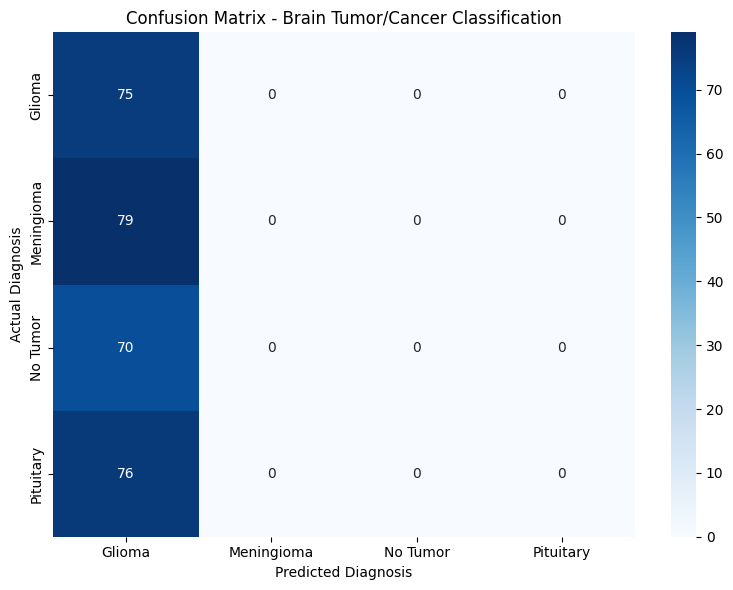

Final Evaluated Loss: 6.4513
Final Evaluated Accuracy: 25.00%


In [ ]:
y_pred_probs = model.predict(X_test_raw)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Performance Report ---\n")
print(classification_report(y_test_raw, y_pred, target_names=class_names))

# Compute and plot the Confusion Matrix
cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor/Cancer Classification')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.tight_layout()
plt.show()

# Evaluate loss and accuracy
loss, accuracy = model.evaluate(X_test_raw, y_test_raw, verbose=0)
print(f"Final Evaluated Loss: {loss:.4f}")
print(f"Final Evaluated Accuracy: {accuracy * 100:.2f}%")